# CIFAR-10 Autoencoder with GPU Acceleration - Final Project Report
**Group: 15**

---


# **1. Problem Description**


## 1.1 Problem Statement and Motivation


Trong thời đại xã hội phát triển như vũ bão, AI dần khẳng định vị thế chiến lược trong đời sống và việc làm của vô số người. Nhằm ngày càng mở rộng và cải tiến công nghệ, học máy là một trong các kỹ thuật phổ biến nhất được áp dụng trong việc nghiên cứu và ứng dụng AI. Bên cạnh các đột phá, còn tồn tại nhiều hạn chế và thách thức trong việc áp dụng, triển khai phương pháp này.

Một thách thức đặc trưng của học máy là làm thế nào để tự động phát hiện các biểu diễn dữ liệu tốt, phản ánh cấu trúc tiềm ẩn của dữ liệu mà không phụ thuộc vào nhãn dán có sẵn. Vì suy cho cùng, các nhãn vẫn mang yếu tố chủ quan trong chúng, nên chắc chắn không thể khái quát hóa lên cao, mà chính sự tổng quát hóa mới giúp ta khám phá và thúc đẩy các giới hạn trong lĩnh vực nghiên cứu AI nói riêng, khoa học máy tính nói chung.

Do đó, nhóm em triển khai một hệ thống để học các đặc trưng một cách không giám sát dựa trên autoencoder, sử dụng dữ liệu mẫu là bài toán phân loại ảnh với bộ dữ liệu CIFAR-10, giúp đương đầu khó khăn phải tìm ra đặc trưng, các mẫu (pattern) của dữ liệu mà có tính tổng quát, khái quát.

Phương pháp học có giám sát truyền thống huấn luyện mô hình bằng các ví dụ có nhãn. Song, autoencoder cố gắng giải quyết vấn đề trên bằng cách cố gắng tìm ra các đặc trưng nổi bật nhất của tập dữ liệu mà không phụ thuộc vào nhãn. Bằng cách này, ta có thể phát hiện các đặc trưng bền vững và tổng quát hơn so với cách tiếp cận thông thường.

**Hệ thống có hai giai đoạn chính:**

**Giai đoạn 1 – Học đặc trưng không giám sát:**

- Huấn luyện một autoencoder tích chập để trích xuất các đặc trưng ý nghĩa nhất từ ảnh.
- Bộ mã hóa (encoder) nén ảnh 32×32×3 thành vector đặc trưng 8.192 chiều. Không sử dụng nhãn trong giai đoạn huấn luyện này. Mạng học được các mẫu thị giác quan trọng (cạnh, kết cấu, hình dạng, v.v.).

**Giai đoạn 2 – Phân loại có giám sát:**

- Trích xuất đặc trưng từ encoder đã huấn luyện cho toàn bộ tập ảnh.
- Huấn luyện bộ phân loại SVM trên các đặc trưng đã học với nhãn lớp.
- Đánh giá hiệu quả phân loại trên tập kiểm thử.


## 1.2 CIFAR-10 Dataset Overview


![image.png](image.png)

**Đặc điểm bộ dữ liệu:**
- **Kích thước ảnh:** 32×32 pixel (màu RGB)
- **Số lớp:** 10 loại (máy bay, ô tô, chim, mèo, nai, chó, ếch, ngựa, tàu thủy, xe tải)
- **Tập huấn luyện:** 50.000 ảnh (5.000 ảnh mỗi lớp)
- **Tập kiểm thử:** 10.000 ảnh (1.000 ảnh mỗi lớp)
- **Định dạng:** Nhóm sẽ làm với tệp nhị phân với giá trị pixel uint8 [0-255]
- **Cách tổ chức của các tập tin nhị phân**: Sẽ có 6 file nhị phân, lần lượt là `data_batch_1.bin` đến `data_batch_5.bin` và `test_batch.bin`, mỗi file có cấu trúc như sau:
    ```
    <1 x label><3072 x pixel>
    ...
    <1 x label><3072 x pixel>
    ```

**Các bước tiền xử lý:**
- Tải các tệp CIFAR-10 nhị phân theo yêu cầu, hoặc 5 batch huấn luyện cùng lúc, hoặc 1 batch kiểm thử
- Phân tích định dạng nhị phân: 1 byte nhãn + 3.072 byte (3x32×32) mỗi ảnh
- Giúp mô hình học nhanh và ổn định hơn, tránh hiện tượng gradient quá lớn hoặc quá nhỏ, đồng thời đảm bảo các giá trị đầu vào nằm trong cùng một khoảng, phù hợp với hàm kích hoạt ReLU, ta chuẩn hóa dữ liệu uint8 [0-255] sang float [0-1].
- Vì mỗi ảnh đã được lưu dưới dạng 1024 bytes đầu tiên là red channel, 1024 bytes tiếp theo là green channel và cuối cùng là blue. Ở mỗi channel dữ liệu được lưu theo row-major order. Dạng dữ liệu này đã phù với việc tính toán ma trận trong huấn luyện huẩn luyện mô hình (`tensor [NCHW]`) nên ta tiến hành load trực tiếp dữ liệu không cần chuyển đổi thứ tự.
- Đồng thời các hàm cơ bản của một dataloader cũng được triển khai như `shuffle` (xáo trộn vị trí các mẫu trong data), `load_batch` (chia data thành các batch để tối ưu training).

## 1.3 Autoencoder Architecture


**Tổng quan kiến trúc của Autoencoder:**

![image-2.png](image-2.png)

```
Input: (32×32×3) → Encoder → Latent: (8×8×128) = 8,192 đặc trưng → Decoder → Output: (32×32×3)
```

Autoencoder có 2 phần chính là **Encoder** và **Decoder**. Encoder được xem là phần để `mã hóa` dữ liệu (ở đây là ảnh) thành 1 dạng biểu diễn khác và dùng Decoder để `tái tạo` lại ảnh ban đầu từ dữ liệu đã được mã hóa.

    Dưới đây là cấu trúc chi tiết về dimension ở các layers của mô hình:

**Encoder (Downsampling):**
- Input: (32, 32, 3)
- Conv2D(256 filters, 3×3, padding=1) + ReLU → (32, 32, 256)
- MaxPool2D(2×2, stride=2) → (16, 16, 256)
- Conv2D(128 filters, 3×3, padding=1) + ReLU → (16, 16, 128)
- MaxPool2D(2×2, stride=2) → (8, 8, 128)
- **Latent representation: (8, 8, 128) = 8,192 dimensions**

**Decoder (Upsampling):**
- Latent: (8, 8, 128)
- Conv2D(128 filters, 3×3, padding=1) + ReLU → (8, 8, 128)
- Upsample2D(2×2) → (16, 16, 128)
- Conv2D(256 filters, 3×3, padding=1) + ReLU → (16, 16, 256)
- Upsample2D(2×2) → (32, 32, 256)
- Conv2D(3 filters, 3×3, padding=1) → (32, 32, 3)
- Output: (32, 32, 3)

    - Cấu trúc của encoder:
        - Các convolution layers, các filter được sử dụng để trích xuất, nhận biết các đặc trưng đặc biệt, quan trọng của bức ảnh.
        - Các maxpool layers dùng để giảm chiều của dữ liệu (ví dụ `[32, 32, 256]` → `[16, 16, 128]`). Thông qua quá trình này, số lượng phép tính mà mô hình phải thực hiện được giảm đi, đồng thời nó cũng bắt mô hình chỉ giữ lại các đặc trưng nổi bật, quan trọng nhất.
        > Thông qua quá trình này, chiều của dữ liệu được tăng lên, nhưng đồng thời các đặc trưng của ảnh được lưu ở lại nhiều hơn, điều rất quan trọng cho việc tái tạo lại ảnh.
    
    - Cấu trúc của latent space:
        - Ảnh input ban đầu có  $32 \times 32 \times 3 = 3,072$ giá trị nhưng khi biểu diễn ở latent space lại có tới $8 \times 8 \times 128 = 8,192$ giá trị.
        - Ở bước này dữ liệu không còn có thể xem như ảnh ban đầu. Thay vì biểu diễn ở các giá trị pixel rời rạc thì ở chiều dữ liệu cao hơn này, mỗi mẫu thể hiện được nhiều thông tin hơn ví dụ: "*có xuất hiện cánh máy bay*", "*có bánh xe tải*",...
    
    - Cấu trúc của decoder:
        - Khối decoder được dùng để tái tạo lại ảnh ban đầu, ta có thể nhận thấy cấu trúc của khối này như đối xứng so với encoder. Ngược lại với maxpool ta dùng Upsample, thay đổi số filter của convolution để tái tạo lại chiều cấu trúc ảnh ban đầu.




## 1.4 Mục tiêu



**Hiệu năng:**
- Thời gian huấn luyện autoencoder cho 50.000 ảnh huấn luyện: < 20 phút
- Thời gian trích xuất đặc trưng (50.000 ảnh huấn luyện + 10.000 ảnh test): < 30 giây
- Độ chính xác phân loại kiểm thử: 60-65%

**Kiến thức và trải nghiệm:**
- Hiện thực các phép toán deep learning từ đầu bằng C++/CUDA
- Thành thạo hơn về lập trình GPU: kernel, quản lý bộ nhớ, tối ưu hóa
- Hiểu và cài đặt được kiến trúc autoencoder ở mức độ cơ bản
- Biết quan sát và tối ưu hóa bằng cách áp dụng các phương pháp song song hóa lên GPU
- Biết tư duy, tìm tòi để cải tiến các phiên bản chạy trên GPU một cách có hệ thống

**Tiêu chí thành công:**
- Pipeline hoàn chỉnh, có thể xử lí từ ảnh gốc đến ra kết quả phân loại cho phiên bản cài bằng CPU, GPU
- Các sự cài đặt của module, layers, ... đều vượt qua unit test kiểm thử, đảm bảo tính đúng đắn
- Cài đặt đúng, có kiểm chứng đối chiếu với phiên bản CPU sơ khai
- Đo lường được mức độ tăng tốc thông qua tối ưu GPU
- Độ chính xác phân loại đạt tối thiểu 60-65%
- Có ghi chú tài liệu rõ ràng về các chiến lược tối ưu và kết quả tương ứng


# **2. Implementation phases**

## **2.1 CPU baseline implementation**


### **2.1.1 Mục tiêu**

- Thiết lập phiên bản cơ sở trên CPU cho toàn bộ kiến trúc, từ học không giám sát đến phân loại có giám sát: xác thực tính đúng đắn và đo lường các chỉ số hiệu năng cơ bản: thời gian, độ mất mát, mức sử dụng bộ nhớ  
- Cung cấp một phiên bản tham chiếu để kiểm chứng tính chính xác của các phiên bản tối ưu hóa  
- Làm rõ các nút thắt hiệu năng (performance bottlenecks), xác định tiềm năng cho việc tối ưu hóa cho các giai đoạn tiếp theo

### **2.1.2 Chi tiết cài đặt**

#### Data pipeline
- Nạp trực tiếp các tệp nhị phân vào các mảng float cấp phát động
- Duyệt tuần tự theo từng byte, từng batch, trích xuất giá trị pixel và nhân với NORMALIZATION_FACTOR (1/255)
- Sử dụng biến random kiểu `std::mt19937` (The classic Mersenne Twister) cho việc xáo trộn (shuffle)
#### Cài đặt các layers
##### Conv2D
- Thực hiện phép tích chập 2D với nhiều channel, hỗ trợ padding, stride, khởi tạo trọng số theo phương pháp Xavier/He.
- **Cài đặt:**
    - Forward: Lặp qua batch, output channel, spatial, input channel, kernel để tính tổng có cộng bias. Xử lý padding bằng kiểm tra chỉ số.
    - Backward: Tính gradient cho input, trọng số, bias bằng cách lặp tương tự, cộng dồn gradient theo công thức chain rule.
    - Cập nhật trọng số: SGD, với weight -= lr * grad.
    - Trọng số và bias lưu dưới dạng vector 1 chiều, ánh xạ chỉ số thủ công (manual - tự tính để chuyển từ chỉ số 4 chiều sang chỉ số 1 chiều)

##### ReLU
-  Hàm gán 0 cho giá trị âm
- **Cài đặt:** 
    - Forward: Duyệt toàn bộ tensor, gán max(0, x).
    - Backward: Gradient truyền qua nếu input > 0, ngược lại bằng 0.

##### MaxPool
- Lấy giá trị lớn nhất trong mỗi cửa sổ pooling (thường 2x2), giảm chiều dữ liệu.
- **Cài đặt:**
    - Forward: Duyệt từng cửa sổ, tìm giá trị lớn nhất và lưu lại chỉ số (index) để dùng cho backward.
    - Backward: Gradient chỉ truyền về vị trí có giá trị lớn nhất, các vị trí còn lại bằng 0.

##### Upsample
- Tăng kích thước bằng phép lặp lại giá trị (nearest neighbor).
- **Cài đặt:**
    - Forward: Mỗi pixel output lấy giá trị từ pixel input gần nhất (theo scale).
    - Backward: Gradient cộng dồn về pixel input tương ứng từ nhiều pixel output.
    - Forward: Mỗi pixel output lấy giá trị từ pixel input gần nhất (theo scale).
    - Backward: Gradient cộng dồn về pixel input tương ứng
#### Training loop
- Đầu tiên, tải dữ liệu lên, khởi tạo theo dõi thông số về bộ nhớ, thời gian
- Thực hiện chạy với 500 ảnh và 2 epochs
- Chạy theo epoch, trong mỗi epoch sẽ duyệt qua từng batch để lần lượt đưa dữ liệu vào autoencoder (forward và backward pass) rồi ghi nhận, hiển thị các thông tin về loss, thời gian, bộ nhớ
- Mỗi epoch sẽ lưu lại thông số ảnh gốc và ảnh tái tạo (chạy qua forward pass của autoencoder), để về sau trực quan hóa


#### Key code snippets
- Convolution function signature:
```cpp
        Conv2DCPU(int in_channels_num, int out_channels_num, int kernel_size, int stride = 1, int padding = 0);
        Tensor forward(const Tensor &input);
        Tensor backward(const Tensor &input);
        void set_weight(const std::vector<float> &weights, const std::vector<float> &bias);
        void get_weights(std::vector<float> &weights, std::vector<float> &bias) const;
        void get_gradients(std::vector<float> &grad_w, std::vector<float> &grad_b);
        void update_weights(float learning_rate);
```

- Main loop structure:
```cpp
        std::vector<float> losses;
        std::vector<double> epoch_times;
        std::vector<size_t> epoch_memory;
        auto train_start = std::chrono::high_resolution_clock::now();

        for (int ep = 0; ep < SUB_EPOCHS; ++ep)
        {

            auto ep_start = std::chrono::high_resolution_clock::now();
            loader.shuffle();

            int batches = TRAIN_IMAGES / BATCH_SIZE;
            double ep_loss = 0.0;

            for (int b = 0; b < batches; ++b)
            {
                float *batch_data = loader.get_batch(BATCH_SIZE);

                Tensor batch_tensor({BATCH_SIZE, 3, 32, 32}, false);
                std::memcpy(batch_tensor.raw_data(), batch_data, BATCH_SIZE * 3 * 32 * 32 * sizeof(float));

                // Forward pass
                Tensor output = model.forward(batch_tensor);
                float batch_loss = model.compute_loss(output, batch_tensor);
                ep_loss += batch_loss;

                // Backward pass
                model.backward(batch_tensor, LEARNING_RATE);

                // Display batch loss
                // ...
                
            }


            // process time, memory...

            // print out info...

            // Save original and reconstruction images

            float *sample_data = loader.get_batch(BATCH_SIZE);
            Tensor sample_tensor({BATCH_SIZE, 3, 32, 32}, false);
            std::memcpy(sample_tensor.raw_data(), sample_data, BATCH_SIZE * 3 * 32 * 32 * sizeof(float));

            Tensor reconstructed = model.forward(sample_tensor);

            ImageUtils::save_reconstruction_samples(
                sample_tensor, reconstructed,
                std::string(MODEL_SAVE_DIR), "epoch_" + std::to_string(ep + 1), 1);
        }
```


### **2.1.3 Kết quả**


- Thời gian huấn luyện:
    - Epoch 1: 2067.75s
    - Epoch 2: 1859.52s
    - Tổng: 3927.27s (~65-66 phút)
- Final reconstruction loss: 0.141507
- Mức độ sử dụng bộ nhớ cao nhất:
    - Epoch 1: 222.79 MB
    - Epoch 2: 217.04 MB
- So ảnh gốc với ảnh tái tạo:
![reconstruction](rescontruction.png)

### **2.1.4 Nhận xét**



- Nhận xét về thuật toán
    - Thuật toán bao gồm hai bước lớn, huấn luyện autoencoder, trích xuất đặc trưng và huấn luyện và chạy SVM
    
    - Hai bước trên cần sự tuần tự thực hiện, tuy nhiên, trong mỗi bước đều có yếu tố có thể song song hóa vì xử lí theo từng ảnh input, mà các ảnh này không liên quan đến nhau. Trong mỗi ảnh, các pixel cũng có tính chất độc lập với nhau.
    
    - Huấn luyện autoencoder tốn nhiều thời gian nhất, nhưng cũng ảnh hưởng lớn nhất đến độ chính xác toàn bộ pipeline

- Những phát hiện định hướng cho bản GPU
    
    - Việc thực hiện tích chập có thể song song hóa vì thao tác trên mỗi output pixel không phụ thuộc nhau
    
    - Có nhiều ảnh nhưng các ảnh không liên quan đến nhau, và các pixel trên mỗi ảnh cũng độc lập lẫn nhau nên toàn bộ thao tác tương tác, xử lí trên ảnh đều song song hóa được

## **2.2 GPU Naive Implementation**

### **2.2.1 Mục tiêu**

Để cải thiện thời gian thực hiện huấn luyện, tiếp theo ta tiến hành chuyển đổi mã nguồn từ CPU sang GPU với các phương thức song song hóa cơ bản. Mục tiêu của phiên bản mã nguồn GPU đơn giản này là giúp xác định hướng đi đúng ban đầu, xác thực tính đúng đắn cho các thuật toán ở phiên bản song song nhằm phục vụ cho những lần cải tiến tiếp theo.

### **2.2.2 Chi tiết cài đặt**

**Ý tưởng chính:**

- Mỗi thread đảm nhận tính toán cho một phần tử đầu ra tại vị trí cụ thể (h, w) của một ảnh (n) và một kênh (c).
- Tạo cấu trúc dữ liệu tensor để lưu trữ các thông tin của dữ liệu (batch, channel, height, width) của các mẫu nhằm phụ vụ cho việc tính toán dựa trên chỉ số ma trận. 
- Về cơ bản, mỗi grid có 3 chiều, ta sẽ sử dụng chúng để đại diện cho các chiều dữ liệu kiểu tensor.
**Cài đặt các layers:**
1. **Convolution Kernel:**
   - Mỗi thread đảm nhận tính toán cho một pixel đầu ra (output pixel) tại vị trí (n, c_out, h_out, w_out).
   - Thread xác định vị trí output dựa trên blockIdx và threadIdx.
   - Trong mỗi thread, thực hiện vòng lặp qua toàn bộ kernel (kích thước kH × kW) và các kênh đầu vào (C_in) để tính tổng tích chập.
   - Sử dụng bộ nhớ toàn cục (global memory) để đọc input, weights, bias và ghi output.
Kiểm tra điều kiện padding để tránh truy cập ngoài biên.

* kernel
```cpp
   __global__ void conv2d_forward_kernel_naive(
    const float* __restrict__ input,
    const float* __restrict__ weights,
    const float* __restrict__ bias,
    float* __restrict__ output,
    int N, int C_in, int H_in, int W_in,
    int C_out, int H_out, int W_out,
    int kH, int kW,
    int stride, int padding,
    bool apply_relu) {
      int n = blockIdx.x;
      int c_out = blockIdx.y;
      int hw = blockIdx.z * blockDim.x + threadIdx.x;
      
      int h_out = hw / W_out;
      int w_out = hw % W_out;
      
      if (n >= N || c_out >= C_out || h_out >= H_out || w_out >= W_out) return;
      
      float sum = 0.0f;
      
      for (int c_in = 0; c_in < C_in; c_in++)        // iterate over input channels
         for (int kh = 0; kh < kH; kh++)            // iterate over kernel height
            for (int kw = 0; kw < kW; kw++)        // iterate over kernel width
                  ......

      sum += bias[c_out];
    }

```

* Khi gọi hàm
```cpp
   int threads = 256;
   int blocks_z = (H_out * W_out + threads - 1) / threads;
   dim3 grid(N, C_out, blocks_z);
   dim3 block(threads);

   conv2d_forward_kernel_naive<<<grid, block>>>(
      input.d_data, weights.d_weights, weights.d_bias, output.d_data,
      N, C_in, H_in, W_in, C_out, H_out, W_out,
      kernel_h, kernel_w, stride, padding, apply_relu
   );

```

2. **ReLU Kernel:**
   - Mỗi thread xử lý một phần tử duy nhất trong tensor. Cách thực hiện tính toán vẫn như trên phiên bản CPU.

3. **MaxPooling Kernel:**
   - Tương tự như ReLu Kernel, mỗi thread chỉ thực hiện tính toán trên một phần tử đầu ra.
   - Thread xác định vị trí output (n, c, h_out, w_out).
   - Duyệt qua cửa sổ pooling (thường 2×2), tìm giá trị lớn nhất và lưu lại chỉ số (index) để dùng cho backward.

4. **Upsampling Kernel:**
   - Thread xác định vị trí output (n, c, h_out, w_out).
   - Tính toán vị trí tương ứng trên input (nearest neighbor) và gán giá trị.

**Memory Management:**
- Sử dụng cudaMalloc để cấp phát bộ nhớ cho weights, activations, gradients trên device.
- Sử dụng cudaMemcpy để truyền dữ liệu từ host sang device (input, weights, labels) và ngược lại (output, loss).

### **2.2.3 Kết quả**


Thông tin tổng quan 

| Metric                    | Value      |
|---------------------------|------------|
| Total training time       | 9213.01 s  |
| Average time per epoch    | 460.65 s   |
| GPU memory usage          | 390 MB     |

Bảng so sánh thời gian chạy của GPU Naive

![training_time_naive.png](training_time_naive.png)

Line chart so sánh thời gian chạy tích lũy so với CPU của GPU Naive

![cumulative_speedup_naive.png](cumulative_speedup_naive.png)



### **2.2.4 Phân tích Profiling**


Hình ảnh Profiling của GPU Naive

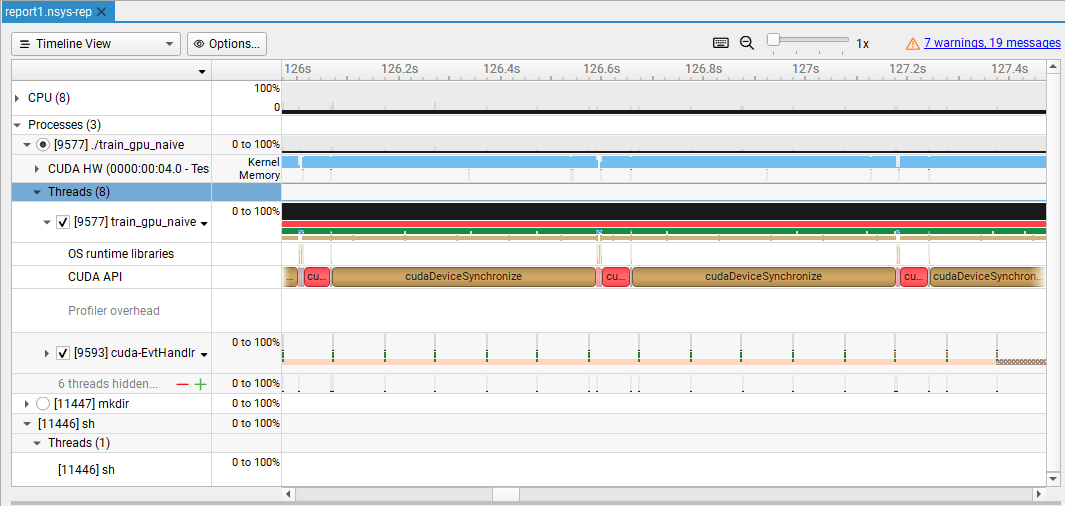

Dựa vào kết quả profiling xuất ra `naive.txt`, ta có:

**CUDA API Summary (cuda_api_sum):**

| Time (%) | Total Time (ns) | Name                                   |
|----------|-----------------|----------------------------------------|
| 88.9     | 404017436921    | cudaDeviceSynchronize                  |
| 9.7      | 44096619630     | cudaMemcpy                             |
| 0.8      | 3651636133      | cudaFree                               |
| 0.2      | 943011919       | cudaMalloc                             |
| 0.2      | 803852732       | cudaHostAlloc                          |
| 0.2      | 777431142       | cudaFreeHost                           |
| 0.0      | 218249382       | cudaLaunchKernel                       |
| 0.0      | 23650723        | cudaMemset                             |
| 0.0      | 22966488        | cudaMemcpyAsync                        |
| 0.0      | 1315318         | cudaEventCreate                        |
| 0.0      | 92333           | cudaGetDeviceProperties_v2_v12000      |
| 0.0      | 66552           | cudaMemGetInfo                         |
| 0.0      | 29686           | cudaEventRecord                        |
| 0.0      | 5430            | cudaEventSynchronize                   |
| 0.0      | 4627            | cudaEventDestroy                       |
| 0.0      | 1555            | cuModuleGetLoadingMode                 |

**CUDA GPU Kernel Summary (cuda_gpu_kern_sum):**

| Time (%) | Total Time (ns) | Name                                                                                           |
|----------|-----------------|------------------------------------------------------------------------------------------------|
| 45.5     | 204042641337    | conv2d_backward_input_kernel_naive(const float *, const float *, float *, int, int, int, int, int, … |
| 40.7     | 182580449583    | conv2d_backward_weights_kernel_naive(const float *, const float *, float *, int, int, int, int, int, … |
| 9.6      | 43150397847     | conv2d_forward_kernel_naive(const float *, const float *, const float *, float *, int, int, int, in… |
| 3.8      | 16857542283     | conv2d_backward_bias_kernel_naive(const float *, float *, int, int, int, int)                  |
| 0.1      | 543170243       | upsample2d_forward_kernel_naive(const float *, float *, int, int, int, int, int, int, int)     |
| 0.1      | 509334140       | maxpool2d_backward_kernel_naive(const float *, const int *, float *, int, int, int, int)       |
| 0.1      | 393844812       | maxpool2d_forward_kernel_naive(const float *, float *, int *, int, int, int, int, int, int, int, in… |
| 0.1      | 336316651       | upsample2d_backward_kernel_naive(const float *, float *, int, int, int, int, int, int, int)    |
| 0.0      | 32497398        | sgd_update_kernel_naive(float *, const float *, float, int)                                    |
| 0.0      | 13338517        | mse_loss_forward_kernel_naive(const float *, const float *, float *, int)                      |
| 0.0      | 5416769         | mse_loss_backward_kernel_naive(const float *, const float *, float *, int, float)              |

- **Mức độ tận dụng băng thông bộ nhớ:** Thực hiện truy cập trực tiếp vào Global Memory cho mỗi thao tác đọc input, bias trong các vòng lặp lồng nhau, khiến việc truy xuất rất chậm, ảnh hưởng xấu đến tốc độ huấn luyện toàn bộ pipeline

- **Nhận diện các nút thắt hiệu năng ban đầu:**
  - conv2d_backward_input_kernel_naive là nút thắt lớn nhất, việc tính toán đòi hỏi lượng lớn truy cập bộ nhớ. Điều này đồng nghĩa phải truy cập Global Memory nhiều lần và làm chậm toàn bộ pipeline
  
  - Việc gọi cudaDeviceSynchronize nhiều lần (88.9%) chứng tỏ còn chưa tận dụng việc đa luồng, hoặc còn tồn tại nhiều lời gọi cuda API mà khiến các luồng không thực hiện song song được.



### **2.2.5 Nhận xét**



- **Tốc độ thực thi của các kernel**
  - Convolution kernels chậm hơn rất nhiều so với kỳ vọng lý thuyết nếu chỉ nhìn vào số lượng phép tính, nguyên nhân chính là do độ trễ bộ nhớ.
  
  - Các layer như ReLU, MaxPool, Upsample chạy rất nhanh và chiếm thời gian không đáng kể, cho thấy việc tối ưu hóa nên tập trung phần lớn vào convolution.

- **Các vấn đề cần tối ưu:**
  - Sử dụng Shared Memory: load các block dữ liệu (input tile, weight tile) vào Shared Memory để giảm số lần truy cập Global Memory.

  - Sử dụng Constant Memory cho các mảng nhỏ như bias, cũng nhằm mục đích hạn chế truy cập vào Global Memory.

- **Giới hạn băng thông và giới hạn tính toán:**
  - Các kernels đều bị giới hạn bởi memory bound vì bị ảnh hưởng bởi truy xuất vào Global Memory nhiều lần, trong đó các hàm convolution kernels là bị ảnh hưởng nặng nhất vì cần truy cập các pixel ở ảnh input liên tục trong lúc thực hiện tính toán.

  - Các kernels nhìn chung đều có thao tác tính toán đơn giản, chưa bị giới hạn bởi tính toán. 

## **2.3 GPU Optimized Implementation - Version 1**


### **2.3.1 Hướng tiếp cận**


Nhận thấy vấn đề khi thực hiện GPU ở phiên bản trước là lượt truy cập Global memory rất nhiều ở các kernel. Phiên bản tối ưu này tập trung cải thiện vấn đề này bằng cách sử dụng các loại memory khác như Shared memory và Constant memory.



### **2.3.2 Mục tiêu**

- Giải quyết vấn đề "memory bound" của phiên bản Naive, nơi các luồng phải đọc đi đọc lại cùng một dữ liệu từ Global Memory.

- Shared Memory Tiling: Giảm thiểu độ trễ truy cập bộ nhớ toàn cục (Global Memory) bằng cách đưa các vùng dữ liệu input lặp lại nhiều lần vào bộ nhớ chia sẻ (Shared Memory) tốc độ cao.

- Constant Memory: Sử dụng bộ nhớ hằng số (Constant Memory) cho các tham số ít thay đổi và kích thước nhỏ như bias để tận dụng bộ nhớ cache chuyên dụng.

- Mong muốn tăng tốc độ thực thi của kernel convolution (forward pass) do giảm băng thông bộ nhớ yêu cầu.



### **2.3.3 Implementation Details**


**Các phương pháp cải tiến được áp dụng:**

1.  **Shared Memory Tiling cho Convolution Forward:**
    -   **Kỹ thuật:** Chia ảnh đầu vào và output thành các "tile" nhỏ (kích thước 16x16). Mỗi block CUDA sẽ chịu trách nhiệm tính toán một tile output.
    -   **Cách thức:** Các luồng trong block hợp tác (cooperative loading) để tải input tile tương ứng vào Shared Memory.
    -   **Xử lý Halo:** Vì kernel convolution (3x3) cần thông tin từ các pixel lân cận, nên khi load vào Shared Memory, ta cần load thêm vùng biên (halo/padding) xung quanh tile chính. Block size được tăng lên (TILE_W + 2, TILE_H + 2) để xử lý việc này.
    -   **Lợi ích:** Dữ liệu input trong Shared Memory được truy cập nhanh hơn rất nhiều so với Global Memory, và được tái sử dụng bởi nhiều luồng trong block khi tính toán tích chập.

2.  **Constant Memory cho Bias:**
    -   **Kỹ thuật:** Khai báo mảng `__constant__ float c_bias[256]` để lưu trữ bias.
    -   **Lợi ích:** Constant Memory có cơ chế caching riêng, rất hiệu quả khi tất cả các luồng trong một warp cùng đọc một địa chỉ bộ nhớ (điều này xảy ra khi cộng bias cho cùng một channel).


```cpp
// Constant memory for biases
__constant__ float c_bias[256];

// Shared Memory Tiling Kernel
__global__ void conv2d_forward_tiled_kernel(...) {
    // Shared memory for input tile (with halo for 3x3 kernel)
    __shared__ float s_input[TILE_H + 2][TILE_W + 2];
    // ... (Index calculation)

    // Cooperative loading of input tile into shared memory
    // Load main tile element + halo elements
    // ...
    __syncthreads();

    // Convolution from shared memory
    if (h_out < H_out && w_out < W_out) {
        for (int kh = 0; kh < KERNEL_SIZE; kh++) {
            for (int kw = 0; kw < KERNEL_SIZE; kw++) {
                // Access s_input instead of global input
                sum += s_input[ty + kh][tx + kw] * weights[...];
            }
        }
    }
    // ...
}
```

### **2.3.4 Results**


Thông số tổng quát

| Metric                    | Value      |
|---------------------------|------------|
| Total training time       | 3706.07 s |
| Average time per epoch    | 185.30s  |
| GPU memory usage          | 490 MB     |


Bảng so sánh với baseline
| Phase        | Training Time (s) | Speedup (vs CPU) | Incremental Speedup | Memory Usage (MB) | Key Optimization        |
|--------------|-------------------|------------------|---------------------|-------------------|-------------------------|
| CPU Baseline | 3,927,270         | 1.00×            | –                   | 1.0               | –                       |
| GPU Naive    | 9,213.01          | 426.30×          | 426.30×             | 308               | Basic Parallelization   |
| GPU Opt v1   | 3,706.07          | 1,059.80×        | 2.49×               | 490               | Shared memory           |

Bảng so sánh thời gian chạy

![training_time_v1.png](training_time_v1.png)

Line chart so sánh thời gian chạy tích lũy so với CPU

![cumulative_speedup_v1.png](cumulative_speedup_v1.png)


### **2.3.5 Phân tích Profiling**


Hình ảnh Profiling GPU Opt_V1

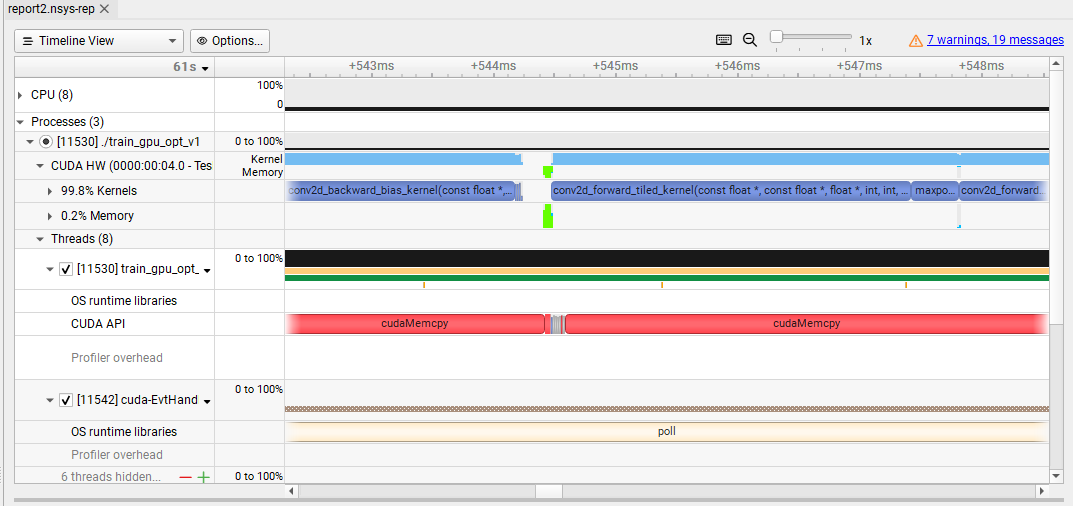

Dựa vào kết quả profiling xuất ra `opt_v1.txt`, ta có


**CUDA API Summary (cuda_api_sum):**

| Time (%) | Total Time (ns) | Name                             |
|----------|-----------------|----------------------------------|
|   99.6   | 182593865678    | cudaMemcpy                       |
|    0.1   |   192558838     | cudaMemGetInfo                   |
|    0.1   |   183710553     | cudaLaunchKernel                 |
|    0.1   |   168304130     | cudaEventSynchronize             |
|    0.0   |    61944018     | cudaMemcpyToSymbol               |
|    0.0   |    26313531     | cudaFree                         |
|    0.0   |    20685226     | cudaMemset                       |
|    0.0   |    18749914     | cudaMalloc                       |
|    0.0   |       91546     | cudaGetDeviceProperties_v2_v12000|
|    0.0   |       19846     | cudaEventRecord                  |
|    0.0   |       18041     | cudaEventCreate                  |
|    0.0   |        6277     | cudaEventDestroy                 |
|    0.0   |        2093     | cuModuleGetLoadingMode           |


 **CUDA GPU Kernel Summary (cuda_gpu_kern_sum):**

| Time (%) | Total Time (ns) | Name                                                                                                   |
|----------|-----------------|--------------------------------------------------------------------------------------------------------|
|   49.6   |  90605998983    | conv2d_backward_weights_kernel(const float *, const float *, float *, int, int, int, int, int, int,…)  |
|   26.9   |  49223107871    | conv2d_forward_tiled_kernel(const float *, const float *, float *, int, int, int, int, int, int, in…)  |
|   13.2   |  24150343062    | conv2d_backward_input_kernel(const float *, const float *, float *, int, int, int, int, int, int, i…)  |
|    9.0   |  16357352406    | conv2d_backward_bias_kernel(const float *, float *, int, int, int, int)                                |
|    0.4   |    787280827    | relu_backward_kernel(const float *, const float *, float *, int)                                       |
|    0.3   |    494254833    | maxpool2d_backward_kernel(const float *, const int *, float *, int)                                   |
|    0.2   |    398089045    | upsample2d_forward_kernel(const float *, float *, int, int, int, int, int, int)                       |
|    0.2   |    341722984    | maxpool2d_forward_kernel(const float *, float *, int *, int, int, int, int, int, int)                 |
|    0.1   |    271662593    | upsample2d_backward_kernel(const float *, float *, int, int, int, int, int, int)                      |
|    0.0   |     32524399    | sgd_update_kernel(float *, const float *, float, int)                                                  |
|    0.0   |      9734258    | mse_loss_forward_kernel(const float *, const float *, float *, int)                                    |
|    0.0   |      3451812    | mse_loss_backward_kernel(const float *, const float *, float *, int, float)                            |

- Ta có thể thấy thời gian thực thi cudaMemcpy đã tăng lên hưng vẫn còn thấp hơn nhiều so với khoảng thời gian đã tốn cho cudaDeviceSynchronize ở bản trước (giảm ~54.80%), và ở phiên bản này hầu như không có cudaDeviceSynchronize - giảm đáng kể so với con số 404017436921ns ở phiên bản trước

- Mặc dù chiếm tỷ trọng phần trăm nhiều nhất ở phiên bản này, conv2d_backward_weights_kernel vẫn nhỏ hơn rất nhiều so với kernel tốn nhiều thời gian nhất ở phiên bản trước là conv2d_backward_input_kernel_naive (nhỏ hơn ~ 44.4%) và cũng đã được tối ưu đáng kể so với bản trước (giảm ~50.37% so với bản trước)

- **Tại sao tối ưu hóa này lại hiệu quả (hoặc không đạt như kỳ vọng)?**
    - Việc sử dụng Shared Memory và Constant Memory cho `conv2d_forward` đã giảm đáng kể số lần truy cập Global Memory, giúp kernel này chạy nhanh hơn rõ rệt.
    - Tuy nhiên, tối ưu hóa này **mới chỉ được áp dụng cho Forward Pass**. Các kernel Backward Pass (tính gradient cho input và weights) vẫn sử dụng cài đặt Naive (truy cập Global Memory trực tiếp).

- **Kết quả profiling cho thấy điều gì?**
    - conv2d_backward_weights_kernel hiện chiếm tỷ trọng thời gian lớn nhất (49.6%)
    - conv2d_forward_tiled_kernel sau khi đã tối ưu chỉ chiếm ~26.9%.
    - Các kernel khác chiếm tỷ trọng rất nhỏ (< 1%).
    - API `cudaMemcpy` chiếm thời gian rất lớn trong tổng thời gian gọi đến các cuda API (99.6%).

- **Nút thắt tiếp theo là gì?**
    - Việc phải gọi nhiều cudaMemcpy đang đồng nghĩa chương trình còn chưa tận dụng được sự song sóng trên nhiều luồng, chưa song song được giữa các kênh truyền dữ liệu

### **2.3.6 Nhận xét**



- **Bài học rút ra:**
    - Kỹ thuật Tiling chứng minh hiệu quả rõ rệt trong việc giảm memory traffic, nhưng đòi hỏi xử lý biên cẩn thận và code phức tạp hơn.
    - Áp dụng thêm Constant Memory vừa dễ cài đặt vừa hiệu quả cho các tham số nhỏ như bias.

- **Cơ hội tối ưu hóa tiếp theo:**
    - Áp dụng hàm truyền dữ liệu không synchronous như cudaMemcpyAsync để khắc phục điểm nghẽn trong pipeline 
    - Áp dụng thêm logic phân luồng để song song thao tác xử lí trên các kênh truyền dữ liệu

## **2.4 GPU Optimized Implementation - Version 2** 

### **2.4.1 Hướng tiếp cận**


- Việc cải thiện tốc độ thực thi của các kernel bằng cách lưu dữ liệu ở vùng nhớ có tốc độ truy cập nhanh hơn đã giảm mạnh thời gian thực thi so với phương pháp ban đầu. Vào bước tối ưu tiếp theo ta sẽ tiến hành song song giữa các luồng làm việc và kết hợp các kernel để giảm thiểu thời gian đọc, ghi dữ liệu giữa các quá trình.

### **2.4.2 Mục tiêu**


- Song song hóa quá trình đọc dữ liệu từ host sang device và quá trình tính toán trên device, đồng thời giảm được thời gian truyền dữ liệu giữa các kernels. Mục tiêu giảm từ 2-5% thời gian thực thi chương trình.

### **2.4.3 Implementation Details**

- Thực hiện song song quá trình chuyển đổi dữ liệu và tính toán GPU:

    - Ở phiên bản này, quá trình sao chép dữ liệu từ host sang device được thực hiện cùng thời điểm với quá trình thực thi kernel bằng CUDA stream. Khi dữ liệu đang được xử lý ở batch này thì dữ liệu được dùng cho batch tiếp theo đã được nạp từ host sang device. Trong khi đó hai bước này được thực hiện tuần tự ở phiên bản trước.

```cpp
    cudaStream_t stream1, stream2;
    cudaStreamCreate(&stream1);
    cudaStreamCreate(&stream2);

    for (int batch = 0; batch < num_batches; ++batch) {
        // Async copy next batch to device while previous batch is computing
        cudaMemcpyAsync(d_input[batch % 2], h_input[batch], batch_size * sizeof(float),
                        cudaMemcpyHostToDevice, (batch % 2 == 0) ? stream1 : stream2);

        // Launch kernel on the stream for this batch
        my_kernel<<<grid, block, 0, (batch % 2 == 0) ? stream1 : stream2>>>(d_input[batch % 2], ...);

        // Optionally, async copy output back
        cudaMemcpyAsync(h_output[batch], d_output[batch % 2], batch_size * sizeof(float),
                        cudaMemcpyDeviceToHost, (batch % 2 == 0) ? stream1 : stream2);
    }
    cudaStreamSynchronize(stream1);
    cudaStreamSynchronize(stream2);
```


- Hợp nhất các kernel:
    - Phiên bản này tiến hành hợp nhất các kernel làm việc liền kề nhau (convolution, activation và pooling). 
    - Sự kết hợp này giảm thiểu việc thực thi nhiều kernel khác nhau, hạn chế việc đọc, ghi dữ liệu vào global memory giữa các layers. 

```cpp
    __global__ void conv2d_relu_fused(const float* input, const float* weights, const float* bias, float* output, ...) {
    // ... index calculation ...
    float sum = 0.0f;
    // Convolution
    for (int c = 0; c < C_in; ++c)
        for (int kh = 0; kh < K; ++kh)
            for (int kw = 0; kw < K; ++kw)
                sum += input[...] * weights[...];
    sum += bias[out_c];
    // Fused ReLU activation
    output[...] = max(0.0f, sum);
    }   
```
- Ngoài ra ở phiên bản này, ta còn thực hiện tiling và coalescing tối ưu hơn.


### **2.4.4 Results**


Thông số tổng quát
| Metric                    | Value      |
|---------------------------|------------|
| Total training time       | 3589.32 s |
| Average time per epoch    | 179.47 s  |
| GPU memory usage          | 490 MB     |


Bảng so sánh với CPU và phiên bản trước
| Phase | Training Time (s) | Speedup (vs CPU) | Incremental Speedup | Memory Usage (MB) | Key Optimization |
|-------|---------------|------------------|---------------------|-------------------|------------------|
| CPU Baseline | 3,927,270 | 1.00× | – | 1.0 | – |
| GPU Opt v1 | 3,706.07 | 1,059.80× | 2.49× | 490 | Shared memory |
| GPU Opt v2 | 3,589.32 | 1,094.60× | 1.03× | 490 | Kernel Fusion + Streams |

Bảng so sánh thời gian chạy

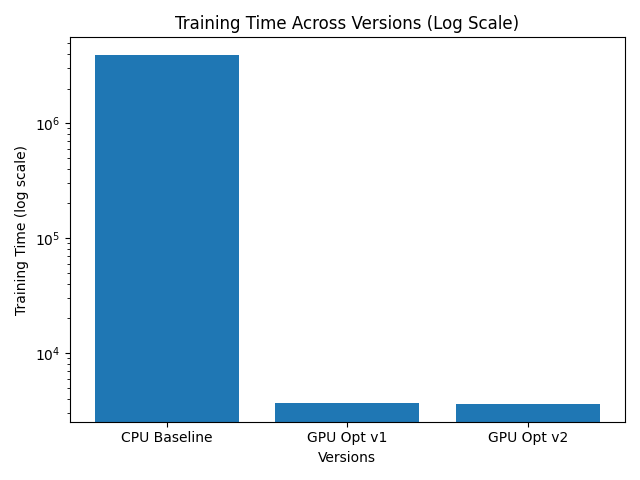

Line chart so sánh thời gian chạy tích lũy so với CPU

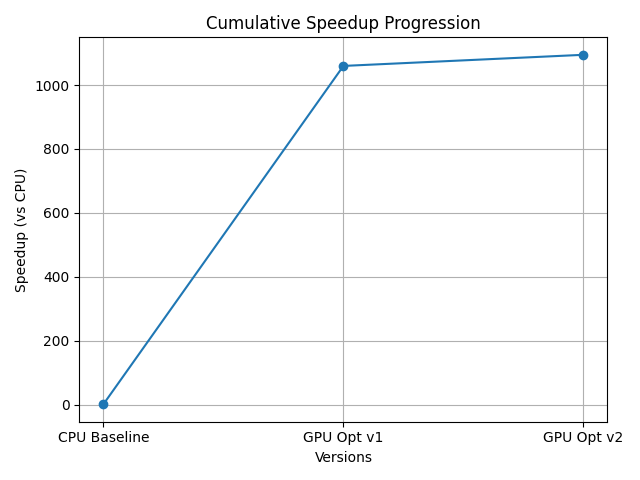


### **2.4.5 Analysis**


Profiling GPU OPT V2

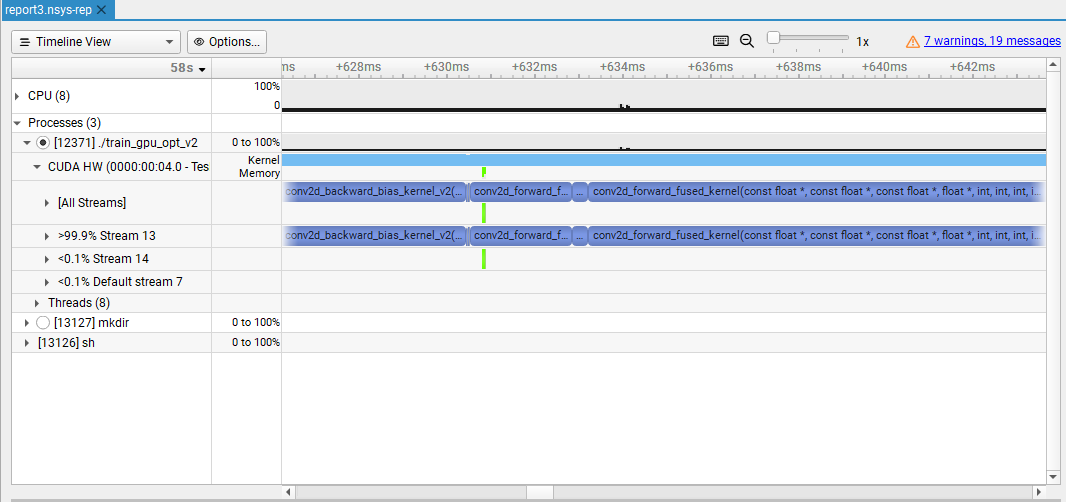

Dựa trên kết quả profiling xuất ra `opt_v2.txt`, ta có:


 **CUDA API Summary (cuda_api_sum):**

| Time (%) | Total Time (ns) | Name                             |
|----------|-----------------|-----------------------------------|
| 96.6     | 172641371751    | cudaLaunchKernel                  |
| 2.8      | 5028316343      | cudaStreamSynchronize             |
| 0.3      | 520209138       | cudaMemcpyAsync                   |
| 0.1      | 249758939       | cudaMemsetAsync                   |
| 0.1      | 190259659       | cudaMemGetInfo                    |
| 0.0      | 10835017        | cudaFree                          |
| 0.0      | 4403256         | cudaEventRecord                   |
| 0.0      | 2526783         | cudaStreamWaitEvent               |
| 0.0      | 2177550         | cudaMemcpy                        |
| 0.0      | 2037392         | cudaMalloc                        |
| 0.0      | 91894           | cudaGetDeviceProperties_v2_v12000 |
| 0.0      | 31115           | cudaStreamCreate                  |
| 0.0      | 22031           | cudaStreamDestroy                 |
| 0.0      | 7834            | cudaEventDestroy                  |
| 0.0      | 5282            | cudaEventCreateWithFlags          |
| 0.0      | 4292            | cudaEventSynchronize              |
| 0.0      | 2558            | cudaEventCreate                   |
| 0.0      | 1944            | cuModuleGetLoadingMode            |

 **CUDA GPU Kernel Summary (cuda_gpu_kern_sum):**

| Time (%) | Total Time (ns) | Name                                                                                                   |
|----------|-----------------|----------------------------------------------------------------------------------------------------------|
| 51.1     | 91180446819     | conv2d_backward_weights_kernel_v2(const float *, const float *, float *, int, int, int, int, int, ...)   |
| 24.5     | 43774711130     | conv2d_forward_fused_kernel(const float *, const float *, const float *, float *, int, int, int, ...)    |
| 13.8     | 24554640619     | conv2d_backward_input_kernel_v2(const float *, const float *, float *, int, int, int, int, int, int ...) |
| 9.3      | 16501649359     | conv2d_backward_bias_kernel_v2(const float *, float *, int, int, int, int)                               |
| 0.4      | 785607692       | relu_backward_kernel_v2(const float *, const float *, float *, int)                                      |
| 0.3      | 492842080       | maxpool2d_backward_kernel_v2(const float *, const int *, float *, int)                                   |
| 0.2      | 408588345       | upsample2d_forward_kernel_v2(const float *, float *, int, int, int, int, int, int)                      |
| 0.2      | 341585076       | maxpool2d_forward_kernel_v2(const float *, float *, int *, int, int, int, int, int, int)                |
| 0.2      | 271354044       | upsample2d_backward_kernel_v2(const float *, float *, int, int, int, int, int, int)                     |
| 0.0      | 32513938        | sgd_update_kernel_v2(float *, const float *, float, int)                                                 |
| 0.0      | 10285786        | mse_loss_forward_kernel_v2(const float *, const float *, float *, int)                                   |
| 0.0      | 3548073         | mse_loss_backward_kernel_v2(const float *, const float *, float *, int, float)                           |

- So với bản cải tiến lần 1, cudaMemcpyAsync đã được khai thác nhiều hơn cho việc song song hóa việc xử lí với việc truyền dữ liệu. Phần lớn thời gian của việc gọi cuda API đến từ cudaLaunchKernel, tăng lên rất nhiều so với ở bản 1, song vẫn nhanh hơn cuda API tốn nhiều thời gian nhất bản 1 là cudaMemcpy (172641371751 < 182593865678)

- Ở phiên bản cải tiến này, kernel liên quan đến thực hiện backward của convolution vẫn chiếm tỉ trọng lớn nhất về mặt thời gian (hơn 50% tổng thời gian của kernel) nhưng đã được tối ưu hóa đáng kể khi chỉ tốn xấp xỉ một nửa thời gian của phiên bản trước. Nói cách khác, sự cải tiến đã giúp rút ngắn gần như gấp đôi thời gian chạy của kernel lâu nhất của phiên bản 1

- Dễ thấy các cải tiến đều nhắm đúng vào các điểm nghẽn, khai thác các tiềm năng xác định ở phiên bản trước, giúp nâng hiệu suất toàn bộ pipeline một cách rõ rệt

### **2.4.6 Nhận xét**


- **Những cách đã tối ưu:**
    
    - Việc gộp các thao tác Convolution, Bias addition và ReLU vào một kernel duy nhất (`conv2d_forward_fused_kernel`) đã chứng minh hiệu quả rõ rệt, giảm thiểu truy cập bộ nhớ dư thừa và overhead khi launch kernel.

    - Việc hiện thực pipeline đa luồng cho phép chồng lấp (overlap) giữa tính toán và truyền dữ liệu, tận dụng tối đa tài nguyên của GPU về tính toán và kênh truyền dữ liệu mặc dù thời gian cải thiện không được cao do bản chất quá trình load dữ liệu từ host sang device của bài toán này (batch size 64) tốn không nhiều thời gian.

- **Những cách tiếp theo có thể tối ưu:**
    
    - Áp dụng các thuật toán tích chập nhanh như Winograd, Im2Col (cuBlas trong CUDA kit) hoặc FFT để cải thiện tốc độ tính toán.
    
    - Kết quả profiling (`opt_v2.txt`) cho thấy `conv2d_backward_weights_kernel_v2` chiếm 51.1% tổng thời gian, đồng nghĩa với một điểm nghẽn có thể được tối ưu thêm.


## **2.5 SVM Integration**


### **2.5.1 Mục tiêu**


- Huấn luyện bộ phân loại SVM trên các đặc trưng đã trích xuất
- Ghi nhận và đánh giá hiệu quả phân loại của pipeline
- Kiểm định chất lượng đặc trưng học được thông qua độ chính xác phân loại


### **2.5.2 Chi tiết cài đặt**


**Trích xuất đặc trưng:**
- Tải trọng số encoder đã huấn luyện từ quá trình training autoencoder
- Thực hiện forward pass qua encoder (không qua decoder) cho toàn bộ tập ảnh huấn luyện (50.000) và tập ảnh kiểm thử (10.000)
- Trích xuất latent space và chuyển đổi từ dạng (N, 8, 8, 128) sang dạng 1 chiều, lưu thành tập tin nhị phân

**Tích hợp LIBSVM:**
- Sử dụng thư viện LIBSVM để huấn luyện và dự đoán SVM
- Tạo ra các hàm khởi tạo svm_nodes, svm_problem, hàm giải phóng vùng nhớ svm_problem, hàm tính gamma
- Dùng các hàm trên để chuyển đổi vector đặc trưng sang định dạng svm_problem với các svm_node cho phù hợp LIBSVM API

**Hyperparameters:**
- Kernel: RBF (Radial Basis Function)
- C: 10.0 (như yêu cầu)
- Gamma: auto (1/N)
- eps: 0.001
- Cache size: 100


Tham số được thiết lập rồi kiểm tra hợp lệ qua `svm_check_parameter` trước khi train.

**Key Code Snippets:**

- Feature extraction code
    ```cpp
    Tensor latent = model.extract_features(batch_tensor);
            const float *latent_data = latent.raw_data();

            for (int i = 0; i < current_batch_size; ++i)
            {
                std::vector<float> feature_vec(FEATURE_DIM);
                std::copy(latent_data + i * FEATURE_DIM,
                          latent_data + (i + 1) * FEATURE_DIM,
                          feature_vec.begin());
                train_features.push_back(std::move(feature_vec));
            }
    ```

- SVM training interface
    ```cpp
    //Forward declaration (function signatures)
    svm_node *create_svm_nodes(const std::vector<float> &features);
    svm_problem *create_svm_problem(const std::vector<std::vector<float>> &features, const std::vector<int> &labels);
    void free_svm_problem(svm_problem *prob);
    double calculate_gamma_auto(int num_features);

    // Setup SVM parameters
        svm_parameter param;
        param.svm_type = C_SVC;
        param.kernel_type = RBF;
        param.gamma = calculate_gamma_auto(feature_dim); // gamma = 1 / num_features
        param.C = 10.0;

        // Create training problem
        cout << "Preparing training data...\n";
        svm_problem *prob = create_svm_problem(train_features, train_labels);

        // Check parameters
        const char *error_msg = svm_check_parameter(prob, &param);

        // Train SVM
        auto start = std::chrono::high_resolution_clock::now();

        svm_model *model = svm_train(prob, &param);

        // Predict on training set
        int train_correct = 0;
        for (int i = 0; i < num_train; ++i)
        {
            svm_node *x = prob->x[i];
            double pred = svm_predict(model, x);
            if ((int)pred == train_labels[i])
            {
                train_correct++;
            }
        }
        double train_accuracy = 100.0 * train_correct / num_train;
    ```

- Prediction and evaluation code
    ```cpp
    // Predict on test set
        int test_correct = 0;
        std::vector<int> predictions(num_test);

        // Confusion matrix
        int confusion[CIFAR_CLASSES][CIFAR_CLASSES] = {0};

        for (int i = 0; i < num_test; ++i)
        {
            svm_node *x = create_svm_nodes(test_features[i]);

            double pred = svm_predict(model, x);
            int pred_label = (int)pred;
            int true_label = test_labels[i];

            predictions[i] = pred_label;

            if (pred_label == true_label)
            {
                test_correct++;
            }

            confusion[true_label][pred_label]++;

            delete[] x;
        }

        double test_accuracy = 100.0 * test_correct / num_test;
    ```


### **2.5.3 Kết quả**


#### Bản CPU
- Thời gian trích xuất đặc trưng (500 mẫu huấn luyện + 500 mẫu kiểm thử): 756.79s
- Thời gian huấn luyện SVM: 8.31494s
- Độ chính xác phân loại trên tập kiểm thử tổng thể: 32%

- Bảng phân tích độ chính xác theo từng lớp (per-class accuracy)

| Class | Accuracy |
|-------|----------|
| airplane | 38.5965% |
| automobile | 39.0244% |
| bird | 15.6863% |
| cat | 8.16327% |
| deer | 50.0000% |
| dog | 8.33333% |
| frog | 42.5926% |
| horse | 21.2766% |
| ship | 42.1053% |
| truck | 51.7857% |

- Confusion matrix

![confusion_cpu](confusion_cpu.png)

- Độ chính xác trên tập huấn luyện: 59.8%


#### Bản GPU

Thông tin tổng quan

| Metric | Value |
|--------|-------|
| Training samples | 50,000 |
| Test samples | 10,000 |
| Feature dimension | 8,192 |

Thời gian chạy và độ chính xác giữa các phiên bản

| Implementation | Feature extraction time (s) | SVM training time (s) | Train accuracy (%) | Test accuracy (%) |
|---------------|----------------------------:|------------------:|-------------------:|------------------:|
| Naive         | 36.50                       | 62.27             | 95.98              | 63.03             |
| Opt_v1        | 29.29                       | 63.47             | 99.37              | 63.97             |
| Opt_v2        | 26.39                       | 62.82             | 98.66              | 66.70             |

Độ chính xác từng class

| Class       | Naive (%) | Opt_v1 (%) | Opt_v2 (%) |
|-------------|-----------:|-----------:|-----------:|
| airplane    | 70.40      | 69.00      | 71.90      |
| automobile  | 71.60      | 73.60      | 76.30      |
| bird        | 49.00      | 49.20      | 52.60      |
| cat         | 48.20      | 51.70      | 52.80      |
| deer        | 55.80      | 57.80      | 62.90      |
| dog         | 55.30      | 53.90      | 57.60      |
| frog        | 71.70      | 71.30      | 73.60      |
| horse       | 65.70      | 67.60      | 70.30      |
| ship        | 75.20      | 75.20      | 77.00      |
| truck       | 67.40      | 70.40      | 72.00      |



##### Confusion matrix Naive
![confusion_naive.png](confusion_naive.png)
##### Confusion matrix Opt_V1
![confusion_v1.png](confusion_v1.png)
##### Confusion matrix Opt_V2
![confusion_v2.png](confusion_v2.png)


### **2.5.4 Phân tích**

#### Bản CPU
- **Những lớp dễ phân loại nhất:** truck (51.79%), deer (50%), frog (42.59%), ship (42.11%), automobile (39.02%), airplane (38.60%).

- **Những lớp khó phân loại nhất:** cat (8.16%), dog (8.33%), horse (21.28%), bird (15.69%).

- **Confusion matrix:** Cho thấy các lớp như cat, dog, horse, bird thường bị nhầm lẫn lẫn nhau và với các lớp khác, đặc biệt là cat và dog. Trong khi các lớp phương tiện (airplane, ship, truck, automobile) phân biệt tốt hơn.

- **Độ chính xác đạt được (32%) thấp hơn kỳ vọng (60-65%)**

- **Nhận xét**: Do chỉ lấy 500 ảnh để train và 500 ảnh để test có thể chưa phản ánh toàn bộ hiệu năng của model, bản GPU sẽ phản ánh tốt hơn.

#### Bản GPU

- **Những lớp dễ phân loại nhất:** Ship (~75–77%) , Automobile (~72–76%), Frog – (71–74%)

- **Những lớp khó phân loại nhất:** Bird (~49–53%), Cat (~48–53%), Dog (~54–58%)

- **Confusion matrix** tương tự như với bản CPU cho thấy các lớp như cat, dog, bird thường bị nhầm lẫn lẫn nhau. Cat và Dog là sự nhầm lẫn nhiều nhất trong khi Bird có sự lẫn giữa Cat và Deer.

- **Độ chính xác đạt được kỳ vọng (60-65%) và hơn ở bản Opt_V2 với 66.7%**

- **Nhận xét**: Được train hết dataset so với bản GPU và dùng thư viện cuML đã giúp việc training cực kì nhanh và đạt được độ chính xác cao, tuy nhiên chất lượng classify cũng phản ánh việc chất lượng autoencoder đủ tốt để phân biệt giữa các class.

### **2.5.5 Nhận xét**

#### Chất lượng features
- Phụ thuộc trực tiếp vào chất lượng autoencoder
- Nếu autoencoder được huấn luyện tốt sẽ giúp phát hiện ra các mẫu đặc trưng của các ảnh, giúp tăng độ chính xác đáng kể mà vẫn đảm bảo tính khái quát hóa
- Chất lượng feature là bottleneck chính của toàn bộ pipeline

#### Pipeline hai giai đoạn có ưu và nhược điểm
- **Ưu**
    - Có thể giám sát, thay đổi, tinh chỉnh autoencoder và SVM mà không ảnh hưởng đến nhau
    - Tách biệt huấn luyện autoencoder với việc áp dụng nó để rút trích đặc trưng rồi chạy classifier, giúp tăng tính tái sử dụng và có thể áp dụng với nhiều classifier khác nhau
    - Mỗi giai đoạn có thể optimize độc lập với các phương pháp song song hóa trên GPU

- **Nhược**
    - Phải train 2 models riêng biệt, có thể có nhiều điểm tối ưu hóa và mở rộng nếu làm thành một pipeline xuyên suốt (việc đọc, ghi, xử lí các dữ liệu, trực quan hóa, ...)
    - Vì các đặc trưng rút trích ra có thể dùng cho nhiều classifier, chưa có tính chuyên biệt cụ thể (chưa bảo đảm chuyên biệt, tối ưu nhất cho SVM trong pipeline hiện tại)
    - Phải tốn thêm không gian lưu trung gian các kết quả ở dạng nhị phân để đảm bảo tính xuyên suốt cả pipeline

#### So sánh với end-to-end supervised learning
- Pipeline này phù hợp khi có nhiều unlabeled data, ít labeled data và có tiềm năng tổng quát hóa (ở giai đoạn rút trích đặc trưng) cao hơn, đồng thời cho phép linh hoạt trong việc áp dụng classifier
- End-to-end supervised learning pipeline cho phép optimize trực tiếp cho classification, có thể có độ chính xác cao hơn nhưng cần nhiều labeled data hơn.


# **3. Comprehensive Performance Analysis**

Vì phiên bản CPU chạy 500 ảnh và 2 epoch và nên chúng em lấy trung bình và nhân lên 100 lần để đủ kích thước dataset và 20 lần đủ đủ số thời gian chạy epochs
## 3.1 Performance Comparison Table

| Phase | Training Time (s) | Speedup (vs CPU) | Incremental Speedup | Memory Usage (MB) | Key Optimization |
|-------|---------------|------------------|---------------------|-------------------|------------------|
| CPU Baseline | 3,927,270 | 1.00× | – | 1.0 | – |
| GPU Naive | 9,213.01 | 426.30× | 426.30× | 308 | Basic Parallelization |
| GPU Opt v1 | 3,706.07 | 1,059.80× | 2.49× | 490 | Shared memory |
| GPU Opt v2 | 3,589.32 | 1,094.60× | 1.03× | 490 | Kernel Fusion + Streams |

## 3.2 Performance Visualizations

### Bar chart comparing training time across phases
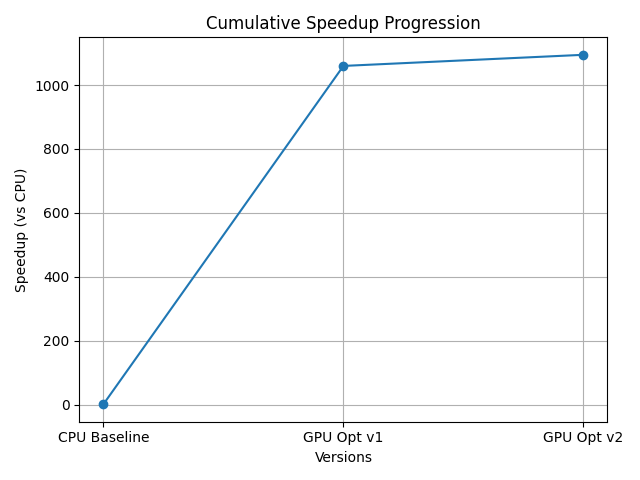
### Line graph showing cumulative speedup progression
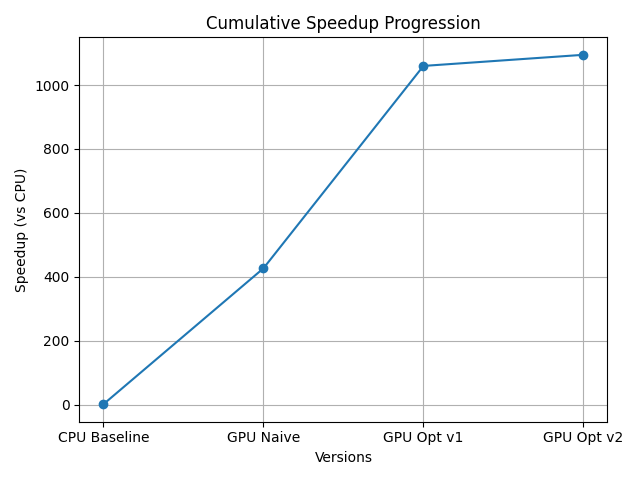

# **4. Lessons Learned and Challenges Overcome**


## 4.1 Key Technical Insights


**CUDA Programming:**
- Memory hierarchy and access patterns
- Thread synchronization and cooperation
- Occupancy and resource utilization
- Kernel launch configuration strategies

**Deep Learning Implementation:**
- Numerical stability considerations
- Gradient flow in deep networks
- Memory-efficient backpropagation
- Weight initialization importance

**Performance Optimization:**
- Profiling-driven optimization methodology
- Trade-offs between memory and compute
- When to apply specific optimization techniques
- Diminishing returns from optimization

## 4.2 Major Challenges and Solutions


*Challenge 1: SVM crash và không phù hợp phiên bản*

![libsvm.jpg](libsvm.jpg)

- *Problem:* Training SVM cho GPU autoencoder version lâu và crash luôn session. 

- *Solution:* Em thực hiện thử cài đặt ThunderSVM nhưng vẫn gặp vấn đề sau đó xử dụng thư viện mới cuML để có thể đưa ra kết quả nhanh.

![thunder.png](thunder.jpg)

- *Lesson:* Train SVM trên CPU rất chậm khi số lượng feature lớn, cần dùng các thư viện GPU phù hợp giúp tối ưu thời gian.

## 4.3 Skills and Knowledge Gained

_Placeholder for:_
- Technical skills acquired
- Tools and techniques mastered
- Understanding deepened
- Practical experience gained


# **5. Conclusion and Future Work**

## 5.1 Project Summary

_Placeholder for project summary:_
- Brief recap of objectives
- Overview of implementation approach
- Summary of phases completed

## 5.2 Final Metrics and Achievements

**Performance Achievements:**

_Placeholder for final metrics:_
- Final training time: _TBD_
- Total speedup achieved: _TBD_
- Classification accuracy: _TBD_
- Memory efficiency: _TBD_

**Objectives Met:**
- ✓ Autoencoder training time: < 10 minutes (_actual: TBD_)
- ✓ Feature extraction time: < 20 seconds (_actual: TBD_)
- ✓ Classification accuracy: 60-65% (_actual: TBD_)
- ✓ GPU speedup: > 20× (_actual: TBD_)

## 5.3 Project Limitations

_Placeholder for limitations:_
- Current constraints and bottlenecks
- Simplifications made in implementation
- Trade-offs accepted
- What couldn't be achieved and why

## 5.4 Future Improvements and Extensions

**Potential Optimizations:**
- _List additional optimization opportunities_
- _Techniques not yet implemented_
- _Advanced CUDA features to explore_

**Architecture Enhancements:**
- Deeper encoder networks
- Different activation functions
- Batch normalization
- Residual connections

**Alternative Approaches:**
- End-to-end supervised learning
- Different loss functions
- Data augmentation
- Transfer learning from pretrained models

**Scalability:**
- Multi-GPU training
- Larger datasets
- Real-time inference optimization

## 5.5 Final Remarks

_Placeholder for final thoughts:_
- Overall experience and learning
- Value of the project
- Applicability to real-world problems
- Future directions for exploration

---

**End of Report**
